In [40]:
import pandas as pd
import os

import kagglehub
from kagglehub import KaggleDatasetAdapter

path = "/Users/harryt/.cache/kagglehub/datasets/waleedfaheem/airline-route-profitability-and-cost-analysis/versions/1"

print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
print(df.head())
print(df.dtypes)
print(df.info())

Files: ['airline_route_profitability.csv']
  Flight_Number Flight_Date Origin Destination    Route     Aircraft_Type  \
0        EK8960  2024-12-20    DXB         ORD  DXB-ORD  Boeing 777-300ER   
1        EK3960  2024-05-13    DXB         HYD  DXB-HYD      Boeing 787-9   
2        EK7529  2024-10-12    DXB         CDG  DXB-CDG      Boeing 787-9   
3        EK4543  2024-06-25    DXB         DEL  DXB-DEL      Boeing 787-9   
4        EK3114  2024-04-20    DXB         RUH  DXB-RUH       Airbus A320   

   Aircraft_Capacity  Passengers  Load_Factor  Flight_Hours  ...  \
0                396         308       0.7791          14.5  ...   
1                296         234       0.7910           4.2  ...   
2                296         251       0.8502           7.5  ...   
3                296         229       0.7748           3.5  ...   
4                180         142       0.7901           2.2  ...   

  Handling_Cost Navigation_Fees Sales_Distribution_Cost  \
0       4460.11        106

In [3]:
print(df.columns.tolist())
print(df.describe())

['Flight_Number', 'Flight_Date', 'Origin', 'Destination', 'Route', 'Aircraft_Type', 'Aircraft_Capacity', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Season', 'Route_Category', 'Demand_Level', 'Ticket_Revenue', 'Ancillary_Revenue', 'Total_Revenue', 'Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost', 'Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees', 'Sales_Distribution_Cost', 'Passenger_Service_Cost', 'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost', 'Total_Cost', 'Profit', 'Profit_Margin']
       Aircraft_Capacity   Passengers  Load_Factor  Flight_Hours  \
count        7974.000000  7974.000000  7974.000000   7974.000000   
mean          317.800602   254.819162     0.801570      6.327314   
std            98.768543    88.141968     0.087755      4.555668   
min           180.000000   104.000000     0.576600      1.200000   
25%           296.000000   180.250000     0.736825      3.200000   
50%           325.000000   246.000000   

In [4]:
import numpy as np

# ---- Hessian of Profit(p, f) = alpha * p - beta * f - gamma ---- #
H = np.array([[0, 0],
              [0, 0]])

eigenvalues = np.linalg.eigvals(H)
print(f"Hessian Eigenvals.: {eigenvalues}")


Hessian Eigenvals.: [0. 0.]


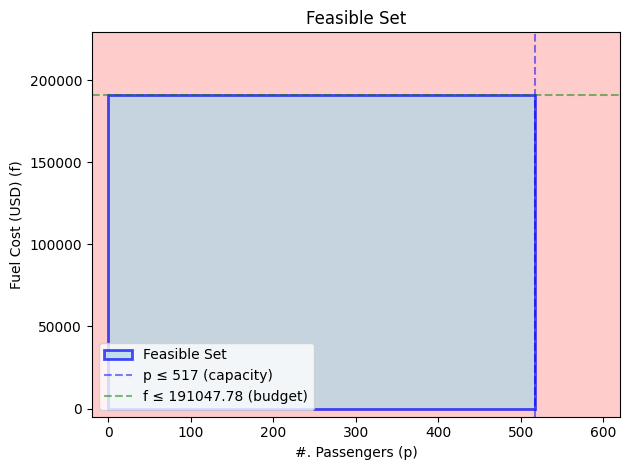

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

C_capacity = df['Aircraft_Capacity'].max()
B_USD = df['Fuel_Cost'].max()

fig, ax = plt.subplots()

ax.set_facecolor('#ffcccc')

rect = patches.Rectangle((0, 0), C_capacity, B_USD,
                          linewidth=2, edgecolor='blue',
                          facecolor='lightblue', alpha=0.7,
                          label='Feasible Set')
ax.add_patch(rect)

ax.axvline(x=C_capacity, color='blue', linestyle='--', alpha=0.5, label=f'p ≤ {C_capacity} (capacity)')
ax.axhline(y=B_USD, color='green', linestyle='--', alpha=0.5, label=f'f ≤ {B_USD} (budget)')

ax.set_xlim(-20, C_capacity * 1.2)
ax.set_ylim(-5000, B_USD * 1.2)
ax.set_xlabel('#. Passengers (p)')
ax.set_ylabel('Fuel Cost (USD) (f)')
ax.set_title('Feasible Set')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
from sklearn.linear_model import LinearRegression

# ---- using passenger, fuel cost, profit columns ---- #
X = df[['Passengers', 'Fuel_Cost']]
y = df['Profit']

# ---- sklearn linear regression ---- #
model = LinearRegression()
model.fit(X, y)

alpha = model.coef_[0]   # revenue / passenger
beta = -model.coef_[1]   # fuel cost coefficient
gamma = -model.intercept_ # misc. operating costs (staff, baggage, etc)

print(f"a (revenue/passenger): {alpha:.2f}")
print(f"b (fuel cost coef): {beta:.2f}")
print(f"g (static costs): {gamma:.2f}")

a (revenue/passenger): 1171.39
b (fuel cost coef): 0.89
g (static costs): 185047.91


In [33]:
from scipy.optimize import linprog

# ---- Use max. values as constraints from dataset ---- #
C_capacity = df['Aircraft_Capacity'].max()   # max passengers
B_USD = df['Fuel_Cost'].max()                # fuel budget

# ---- negate profit coefs. for max.
c = [-alpha, beta]

# ---- inequality constraints & upper bound
A_ub = [[1, 0],
        [0, 1]]
b_ub = [C_capacity, B_USD]

bounds = [(0, C_capacity), (0, B_USD)]

result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

p_opt, f_opt = result.x
profit_opt = alpha * p_opt - beta * f_opt - gamma

print(f"Optimal passengers: {p_opt}")
print(f"Optimal fuel cost: {f_opt}")
print(f"Maximum profit: ${profit_opt}")

Optimal passengers: 517.0
Optimal fuel cost: 0.0
Maximum profit: $420559.98342607333


In [15]:
from scipy.optimize import linprog

# ---- define constraints from dataset ---- #
C_capacity = df['Aircraft_Capacity'].max()   # max. # of passengers
B_USD = df['Fuel_Cost'].max()                # fuel budget (max fuel expense)


In [18]:
# ---- closed-form solution --> solve profits(p,f) at each vertex of set
vertices = {
    '(0, 0)': (0, 0),
    '(C_capacity, 0)': (C_capacity, 0),
    '(0, B_USD)' : (0, B_USD),
    '(C_capacity, B_USD)': (C_capacity, B_USD),
}

print("Closed-form Solution:")
for label, (p, f) in vertices.items():
    profit = alpha * p - beta * f - gamma
    print(f"Profit{label} = ${profit:,.2f}")

Closed-form Solution:
Profit(0, 0) = $-185,047.91
Profit(C_capacity, 0) = $420,559.98
Profit(0, B_USD) = $-355,373.05
Profit(C_capacity, B_USD) = $250,234.84


In [23]:
# ---- compute avg fuel cost / passenger ---- #
delta = df['Fuel_Cost'].sum() / df['Passengers'].sum()

c = [-alpha, beta]

# ---- define constraint matrix to couple each
# ---- constraint to plausible value per the dataset
A_ub  = [[ 1, 0],   # --> p <= C_capacity
         [ 0, 1],   # --> f <= B_USD
         [delta, -1]]   # --> f >= delta*p (coupling)

# ---- define bounds to enforce constraints
b_ub  = [C_capacity, B_USD, 0]
bounds = [(0, C_capacity), (0, B_USD)]

# ---- solve original objective function ---- #
result     = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
p_opt, f_opt = result.x
profit_opt = alpha * p_opt - beta * f_opt - gamma

print("Numerical Solution")
print(f"Optimal passengers: {p_opt}")
print(f"Optimal fuel cost: {f_opt:.2f}")
print(f"Maximum profit: ${profit_opt:.2f}")

Numerical Solution
Optimal passengers: 517.0
Optimal fuel cost: 93930.31
Maximum profit: $336818.14


In [13]:
# ---- See what aircraft to filter out ---- #
print(df['Aircraft_Type'].unique())

<StringArray>
['Boeing 777-300ER',     'Boeing 787-9',      'Airbus A320',
   'Boeing 737-800',  'Airbus A350-900',      'Airbus A380']
Length: 6, dtype: str


In [31]:
# ---- Filter domestic vs international aircraft ---- #
domestic      = ['Boeing 737-800', 'Airbus A320']
international = ['Boeing 787-9', 'Airbus A350-900', 'Boeing 777-300ER']

for label, fleet in [('Domestic', domestic), ('International', international)]:

    df_fleet = df[df['Aircraft_Type'].isin(fleet)]

    # ---- compute constraints
    C_capacity = df_fleet['Aircraft_Capacity'].max()
    B_USD      = df_fleet['Fuel_Cost'].max()
    delta      = df_fleet['Fuel_Cost'].sum() / df_fleet['Passengers'].sum()

    X_fleet = df_fleet[['Passengers', 'Fuel_Cost']]
    y_fleet = df_fleet['Profit']
    model_fleet = LinearRegression().fit(X_fleet, y_fleet)

    alpha_f = model_fleet.coef_[0]
    beta_f  = -model_fleet.coef_[1]
    gamma_f = -model_fleet.intercept_

    # ---- sklearn linprog
    c      = [-alpha_f, beta_f]
    A_ub   = [[ 1,0],
              [ 0,1],
              [delta,-1]]
    b_ub   = [C_capacity, B_USD, 0]
    bounds = [(0, C_capacity), (0, B_USD)]

    result     = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    p_opt, f_opt = result.x
    profit_opt = alpha_f * p_opt - beta_f * f_opt - gamma_f

    print(f"\n{label} Solution")
    print(f"Aircraft: {fleet}")
    print(f"C_capacity: {C_capacity} seats")
    print(f"a (rev/passengers): ${alpha_f}")
    print(f"Optimal # passengers: {p_opt}")
    print(f"Optimal fuel: ${f_opt}")
    print(f"Maximum profit: ${profit_opt}")


Domestic Solution
Aircraft: ['Boeing 737-800', 'Airbus A320']
C_capacity: 189 seats
a (rev/passengers): $177.4208714982369
Optimal # passengers: 189.0
Optimal fuel: $5704.709157005126
Maximum profit: $7369.302992208253

International Solution
Aircraft: ['Boeing 787-9', 'Airbus A350-900', 'Boeing 777-300ER']
C_capacity: 396 seats
a (rev/passengers): $1335.1699773754876
Optimal # passengers: 396.0
Optimal fuel: $77247.49098089332
Maximum profit: $232635.7228198351


In [29]:
# ---- KKT Conditions
lambda1 = alpha        # stationarity: dL/dp = 0 --> α - λ1 = 0
lambda2 = 0            # fuel constraint n/a
lambda3 = beta         # stationarity: dL/df = 0 → -β + λ3...
delta_lambda = delta   # coupling constraint multiplier

print("KKT Conditions")

# ---- Stationary Condition
print(f"\n1. Stationarity:")
print(f"dL/dp = a - l1 = {alpha} - {lambda1} = {alpha - lambda1} ")
print(f"dL/df = -b - l2 = {-beta} - {lambda2} = {-beta - lambda2}")

# ---- Primal Feasibility Condition
print(f"\n2. Primal Feasibility:")
print(f"p* <= C_capacity: {p_opt} <= {C_capacity}")
print(f"f* <= B_USD: {f_opt} <= {B_USD}")
print(f"f* >= delta*p*: {f_opt} >= {delta*p_opt}")

# ---- Dual feasibility
print(f"\n3. Dual Feasibility (lambda ≥ 0):")
print(f"l1 = {lambda1} >= 0")
print(f"l2 = {lambda2} >= 0")

# ---- Complementary slackness
print(f"\n4. Complementary Slackness:")
print(f"l1*(C_capacity - p*) = {lambda1} * {C_capacity - p_opt} = {lambda1*(C_capacity - p_opt)}")
print(f"l2*(B_USD - f*) = {lambda2} * {B_USD - f_opt} = {lambda2*(B_USD - f_opt)}")

KKT Conditions

1. Stationarity:
dL/dp = a - l1 = 1171.388579234406 - 1171.388579234406 = 0.0 
dL/df = -b - l2 = -0.8915316363558464 - 0 = -0.8915316363558464

2. Primal Feasibility:
p* <= C_capacity: 517.0 <= 517
f* <= B_USD: 93930.30580955134 <= 191047.78
f* >= delta*p*: 93930.30580955134 >= 93930.30580955134

3. Dual Feasibility (lambda ≥ 0):
l1 = 1171.388579234406 >= 0
l2 = 0 >= 0

4. Complementary Slackness:
l1*(C_capacity - p*) = 1171.388579234406 * 0.0 = 0.0
l2*(B_USD - f*) = 0 * 97117.47419044866 = 0.0
